- **pandas**: 3.0.5
- **pyarrow**: 25.0.1
- **matplotlib**: 3.11.1
- **seaborn**: 0.13.2
- **numpy**: 2.5.2


## 1. Setup and Imports

Import scientific libraries and configure visual styles following pandas 3.0.x guidelines (Copy-on-Write and native string datatypes).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Pandas version:", pd.__version__)

# Custom Premium Styling (Dark Mode Developer-Dashboard Aesthetic)
DARK_BG = "#0f172a"
CARD_BG = "#1e293b"
GRID_COLOR = "#334155"
TEXT_COLOR = "#f8fafc"
MUTED_TEXT = "#94a3b8"

# Color Accents
PRIMARY_COLOR = "#38bdf8"
ACCENT_COLOR = "#ef4444"
SUCCESS_COLOR = "#10b981"
PURPLE_COLOR = "#a855f7"
ORANGE_COLOR = "#f97316"

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor": DARK_BG,
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": TEXT_COLOR,
    "xtick.color": MUTED_TEXT,
    "ytick.color": MUTED_TEXT,
    "grid.color": GRID_COLOR,
    "text.color": TEXT_COLOR,
    "font.family": "sans-serif",
    "font.sans-serif": ["Inter", "Roboto", "Arial", "sans-serif"],
})

Pandas version: 3.0.5


## 2. Load Datasets & Parse Dates

Load all 8 tables from the `data` directory and parse relevant date columns.

In [2]:
data_dir = "data"

customers = pd.read_csv(os.path.join(data_dir, "olist_customers_dataset.csv"))
order_items = pd.read_csv(os.path.join(data_dir, "olist_order_items_dataset.csv"))
order_payments = pd.read_csv(os.path.join(data_dir, "olist_order_payments_dataset.csv"))
order_reviews = pd.read_csv(os.path.join(data_dir, "olist_order_reviews_dataset.csv"))
orders = pd.read_csv(os.path.join(data_dir, "olist_orders_dataset.csv"))
products = pd.read_csv(os.path.join(data_dir, "olist_products_dataset.csv"))
sellers = pd.read_csv(os.path.join(data_dir, "olist_sellers_dataset.csv"))
category_translation = pd.read_csv(os.path.join(data_dir, "product_category_name_translation.csv"))

# Date Parsing
date_cols = [
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'])

print("All datasets loaded successfully!")

All datasets loaded successfully!


## 3. Data Integrity & Cleaning Checks

Verify table row counts, primary key uniqueness, NULL values, and date/payment value sanity.

In [3]:
# Row Counts
print("--- Row Counts ---")
row_counts = {
    'customers': len(customers),
    'orders': len(orders),
    'order_items': len(order_items),
    'order_payments': len(order_payments),
    'order_reviews': len(order_reviews),
    'products': len(products),
    'sellers': len(sellers),
    'category_translation': len(category_translation)
}
for k, v in row_counts.items():
    print(f"{k:<22}: {v:,} rows")

# PK Uniqueness
print("\n--- PK Uniqueness (Duplicates) ---")
print("customers (customer_id)    :", customers['customer_id'].duplicated().sum())
print("orders (order_id)          :", orders['order_id'].duplicated().sum())
print("products (product_id)      :", products['product_id'].duplicated().sum())

# NULL Checks
print("\n--- NULL Checks ---")
print("customers (customer_id is null) :", customers['customer_id'].isna().sum())
print("orders (order_id is null)       :", orders['order_id'].isna().sum())
print("order_items (order_id is null)  :", order_items['order_id'].isna().sum())
print("order_items (product_id is null):", order_items['product_id'].isna().sum())

# Date/Payment Sanity
print("\n--- Sanity Checks ---")
print("orders (order_purchase_timestamp is null):", orders['order_purchase_timestamp'].isna().sum())
print("order_payments (value <= 0)              :", (order_payments['payment_value'] <= 0).sum())

--- Row Counts ---
customers             : 99,441 rows
orders                : 99,441 rows
order_items           : 112,650 rows
order_payments        : 103,886 rows
order_reviews         : 99,224 rows
products              : 32,951 rows
sellers               : 3,095 rows
category_translation  : 71 rows

--- PK Uniqueness (Duplicates) ---
customers (customer_id)    : 0
orders (order_id)          : 0
products (product_id)      : 0

--- NULL Checks ---
customers (customer_id is null) : 0
orders (order_id is null)       : 0
order_items (order_id is null)  : 0
order_items (product_id is null): 0

--- Sanity Checks ---
orders (order_purchase_timestamp is null): 0
order_payments (value <= 0)              : 9


## 4. Key Business Questions Analysis

Perform business metrics calculations and generate visualizations.

### Q1: Monthly Revenue Trends — Are Sales Growing?

Calculate monthly revenue from delivered orders and compute month-over-month growth. Filter out the anomalous near-zero December 2016 data point in the chart.

,month,revenue,growth_percent
0,2016-10,"$46,566.71",+nan%
1,2016-12,$19.62,-99.96%
2,2017-01,"$127,545.67",+649979.87%
3,2017-02,"$271,298.65",+112.71%
4,2017-03,"$414,369.39",+52.74%
5,2017-04,"$390,952.18",-5.65%
6,2017-05,"$567,066.73",+45.05%
7,2017-06,"$490,225.60",-13.55%
8,2017-07,"$566,403.93",+15.54%
9,2017-08,"$646,000.61",+14.05%


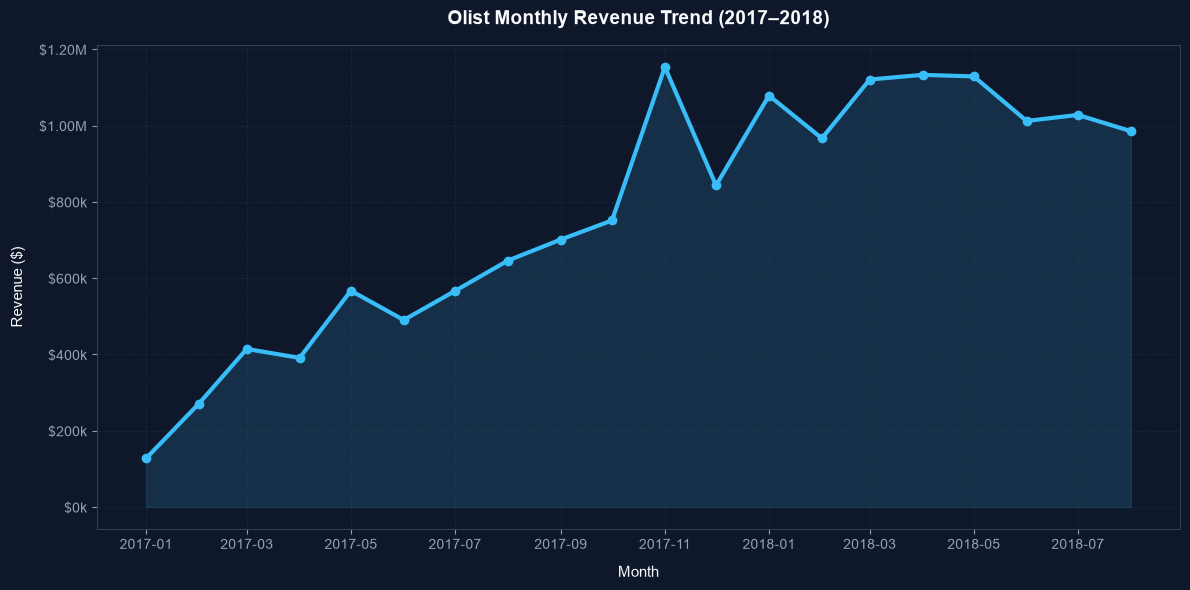

In [4]:
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
rev_merged = orders_delivered.merge(order_payments, on='order_id', how='inner')

rev_merged['month'] = rev_merged['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
monthly_rev = rev_merged.groupby('month', as_index=False)['payment_value'].sum()
monthly_rev = monthly_rev.rename(columns={'payment_value': 'revenue'}).sort_values('month')

monthly_rev['growth_percent'] = monthly_rev['revenue'].pct_change() * 100
monthly_rev['revenue'] = monthly_rev['revenue'].round(2)
monthly_rev['growth_percent'] = monthly_rev['growth_percent'].round(2)

display(monthly_rev.style.format({
    'month': lambda x: x.strftime('%Y-%m'),
    'revenue': '${:,.2f}',
    'growth_percent': '{:+.2f}%'
}))

# Visualizing Revenue Trend
plt.figure(figsize=(12, 6))
chart_rev = monthly_rev[monthly_rev['month'] > '2016-12-01'].copy()
plt.plot(chart_rev['month'], chart_rev['revenue'], color=PRIMARY_COLOR, linewidth=3, marker='o', markersize=6, label='Monthly Revenue')
plt.fill_between(chart_rev['month'], chart_rev['revenue'], color=PRIMARY_COLOR, alpha=0.15)
plt.title("Olist Monthly Revenue Trend (2017–2018)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Month", fontsize=11, labelpad=10)
plt.ylabel("Revenue ($)", fontsize=11, labelpad=10)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x*1e-6:.2f}M" if x >= 1e6 else f"${x*1e-3:.0f}k"))
plt.grid(True, linestyle='--', alpha=0.3, color=GRID_COLOR)
plt.tight_layout()
plt.show()

### Q2: Product Categories — Revenue vs Order Volume

Identify which product categories drive the most revenue vs. highest order volume. Translate Brazilian category names to English using `product_category_name_translation.csv`.

,category,revenue,order_volume
43,health_beauty,"$1,233,131.72","8,647"
73,watches_gifts,"$1,166,176.98","5,495"
7,bed_bath_table,"$1,023,434.76","9,272"
68,sports_leisure,"$954,852.55","7,530"
15,computers_accessories,"$888,724.61","6,530"
39,furniture_decor,"$711,927.69","6,307"
49,housewares,"$615,628.69","5,743"
20,cool_stuff,"$610,204.10","3,559"
5,auto,"$578,966.65","3,810"
72,toys,"$471,286.48","3,804"


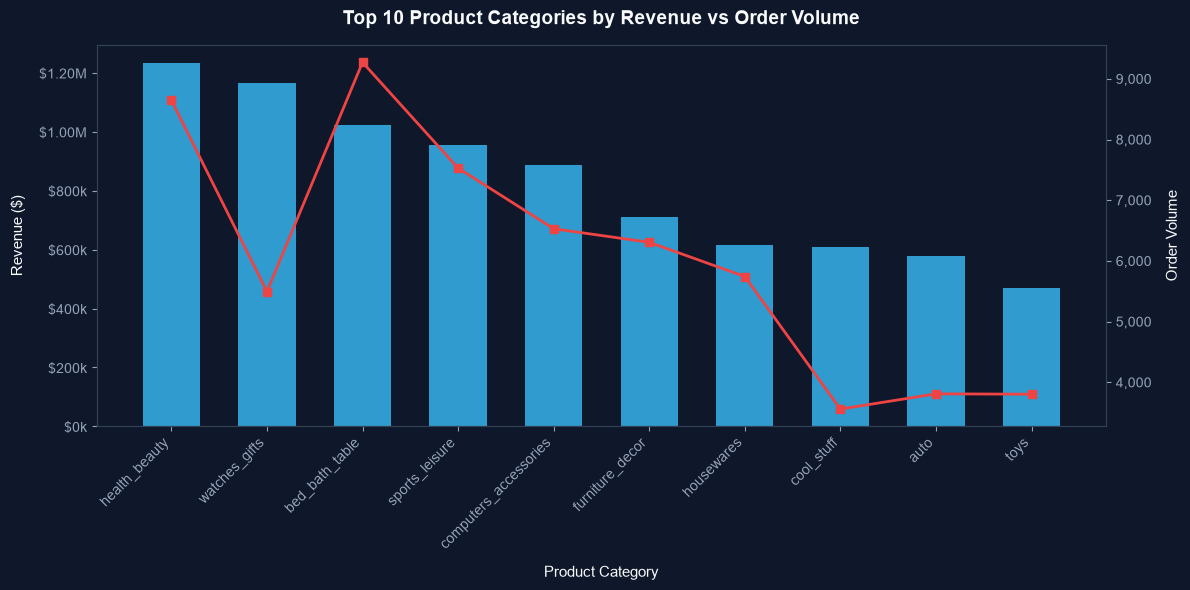

In [5]:
merged_prod = order_items.merge(products, on='product_id', how='inner')
merged_prod = merged_prod.merge(category_translation, on='product_category_name', how='left')
merged_prod = merged_prod.merge(orders_delivered, on='order_id', how='inner')
merged_prod['category'] = merged_prod['product_category_name_english'].fillna(merged_prod['product_category_name'])
merged_prod['category'] = merged_prod['category'].fillna('other')

category_analysis = merged_prod.groupby('category', as_index=False).agg(
    revenue=('price', 'sum'),
    order_volume=('order_id', 'nunique')
)
category_analysis['revenue'] = category_analysis['revenue'].round(2)
category_analysis = category_analysis.sort_values('revenue', ascending=False)

display(category_analysis.head(10).style.format({
    'revenue': '${:,.2f}',
    'order_volume': '{:,}'
}))

# Dual Axis Viz: top 10 categories
top10_cat = category_analysis.head(10).copy()
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel("Product Category", fontsize=11, labelpad=10)
ax1.set_ylabel("Revenue ($)", color=TEXT_COLOR, fontsize=11, labelpad=10)
bars = ax1.bar(top10_cat['category'], top10_cat['revenue'], color=PRIMARY_COLOR, alpha=0.8, width=0.6, label='Revenue')
ax1.tick_params(axis='y', labelcolor=MUTED_TEXT)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x*1e-6:.2f}M" if x >= 1e6 else f"${x*1e-3:.0f}k"))
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.set_ylabel("Order Volume", color=TEXT_COLOR, fontsize=11, labelpad=10)
line = ax2.plot(top10_cat['category'], top10_cat['order_volume'], color=ACCENT_COLOR, linewidth=2, marker='s', markersize=6, label='Order Volume')
ax2.tick_params(axis='y', labelcolor=MUTED_TEXT)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))

plt.title("Top 10 Product Categories by Revenue vs Order Volume", fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

### Q3: Customer Lifetime Value & Repeat Purchases

Calculate the average customer lifetime value (CLV), max customer spending, number of unique customers, and rate of repeat purchases.

In [6]:
cust_orders = orders_delivered.merge(customers, on='customer_id', how='inner')
cust_orders = cust_orders.merge(order_payments, on='order_id', how='inner')

clv = cust_orders.groupby('customer_unique_id', as_index=False).agg(
    num_orders=('order_id', 'nunique'),
    total_spent=('payment_value', 'sum')
)
clv['total_spent'] = clv['total_spent'].round(2)

print(f"Average Customer Spent (CLV) : ${clv['total_spent'].mean():.2f}")
print(f"Max Customer Spent           : ${clv['total_spent'].max():,.2f}")
print(f"Total Unique Customers       : {len(clv):,}")

repeat_cust = clv[clv['num_orders'] > 1]
print(f"Repeat Customers (>= 2 orders): {len(repeat_cust):,} ({len(repeat_cust)/len(clv)*100:.2f}%)")

print("\nTop 10 Customers by Total Spend:")
display(clv.sort_values('total_spent', ascending=False).head(10).style.format({
    'total_spent': '${:,.2f}'
}))

Average Customer Spent (CLV) : $165.20
Max Customer Spent           : $13,664.08
Total Unique Customers       : 93,357
Repeat Customers (>= 2 orders): 2,801 (3.00%)

Top 10 Customers by Total Spend:


,customer_unique_id,num_orders,total_spent
3724,0a0a92112bd4c708ca5fde585afaa872,1,"$13,664.08"
79635,da122df9eeddfedc1dc1f5349a1a690c,2,"$7,571.63"
43168,763c8b1c9c68a0229c42c9fc6f662b93,1,"$7,274.88"
80462,dc4802a71eae9be1dd28f5d788ceb526,1,"$6,929.31"
25436,459bef486812aa25204be022145caa62,1,"$6,922.21"
93080,ff4159b92c40ebe40454e3e6a7c35ed6,1,"$6,726.66"
23411,4007669dec559734d6f53e029e360987,1,"$6,081.54"
87147,eebb5dda148d3893cdaf5b5ca3040ccb,1,"$4,764.34"
26640,48e1ac109decbb87765a3eade6854098,1,"$4,681.78"
73126,c8460e4251689ba205045f3ea17884a1,4,"$4,655.91"


### Q4: Seller Performance — Revenue vs Review Scores

Find sellers with at least 5 orders that balance high revenue and positive customer review scores.

In [7]:
merged_sellers = order_items.merge(sellers, on='seller_id', how='inner')
merged_sellers = merged_sellers.merge(order_reviews, on='order_id', how='inner')

seller_perf = merged_sellers.groupby('seller_id', as_index=False).agg(
    revenue=('price', 'sum'),
    avg_review_score=('review_score', 'mean'),
    num_orders=('order_id', 'nunique')
)
seller_perf = seller_perf[seller_perf['num_orders'] >= 5].copy()
seller_perf['revenue'] = seller_perf['revenue'].round(2)
seller_perf['avg_review_score'] = seller_perf['avg_review_score'].round(2)
seller_perf = seller_perf.sort_values(['revenue', 'avg_review_score'], ascending=[False, False])

print("Top 10 Sellers by Revenue & Review Scores:")
display(seller_perf.head(10).style.format({
    'revenue': '${:,.2f}',
    'avg_review_score': '{:.2f} / 5.0',
    'num_orders': '{:,}'
}))

Top 10 Sellers by Revenue & Review Scores:


,seller_id,revenue,avg_review_score,num_orders
854,4869f7a5dfa277a7dca6462dcf3b52b2,"$228,071.04",4.12 / 5.0,"1,124"
1010,53243585a1d6dc2643021fd1853d8905,"$220,740.05",4.08 / 5.0,356
878,4a3ca9315b744ce9f8e9374361493884,"$200,561.42",3.80 / 5.0,"1,785"
3019,fa1c13f2614d7b5c4749cbc52fecda94,"$192,774.43",4.34 / 5.0,581
1532,7c67e1448b00f6e969d365cea6b010ab,"$188,017.85",3.35 / 5.0,976
1557,7e93a43ef30c4f03f38b393420bc753a,"$176,201.88",4.21 / 5.0,335
2638,da8622b14eb17ae2831f4ac5b9dab84a,"$161,993.97",4.07 / 5.0,"1,308"
1502,7a67c85e85bb2ce8582c35f2203ad736,"$141,130.58",4.23 / 5.0,"1,151"
192,1025f0e2d44d7041d6cf58b6550e0bfa,"$139,484.38",3.85 / 5.0,907
1820,955fee9216a65b617aa5c0531780ce60,"$133,948.81",4.05 / 5.0,"1,277"


### Q5: Delivery Time vs Review Scores

Calculate the Pearson correlation between delivery days and review score, and calculate the average delivery days for each rating level (1-5 stars).

Correlation coefficient (delivery days vs review score): -0.3337


,review_score,delivery_days
0,Rating 1,20.85 days
1,Rating 2,16.19 days
2,Rating 3,13.80 days
3,Rating 4,11.85 days
4,Rating 5,10.22 days


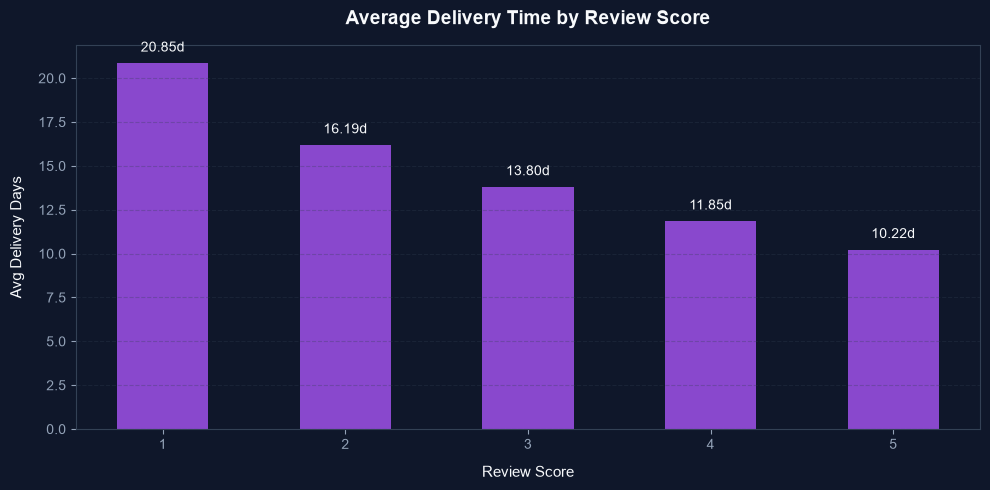

In [8]:
orders_with_delivery = orders[orders['order_delivered_customer_date'].notna()].copy()
merged_delivery = orders_with_delivery.merge(order_reviews, on='order_id', how='inner')

# Day difference calculation
merged_delivery['delivery_days'] = (merged_delivery['order_delivered_customer_date'] - merged_delivery['order_purchase_timestamp']).dt.days

correlation = merged_delivery['delivery_days'].corr(merged_delivery['review_score'])
print(f"Correlation coefficient (delivery days vs review score): {correlation:.4f}")

delivery_by_review = merged_delivery.groupby('review_score', as_index=False)['delivery_days'].mean()
delivery_by_review['delivery_days'] = delivery_by_review['delivery_days'].round(2)
delivery_by_review = delivery_by_review.sort_values('review_score')

display(delivery_by_review.style.format({
    'review_score': 'Rating {}',
    'delivery_days': '{:.2f} days'
}))

# Visualizing Delivery Days vs Review Scores
plt.figure(figsize=(10, 5))
bars = plt.bar(delivery_by_review['review_score'].astype(str), delivery_by_review['delivery_days'], color=PURPLE_COLOR, alpha=0.8, width=0.5)
plt.title("Average Delivery Time by Review Score", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Review Score", fontsize=11, labelpad=10)
plt.ylabel("Avg Delivery Days", fontsize=11, labelpad=10)

# Add values above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f"{yval:.2f}d", ha='center', va='bottom', fontsize=10, color=TEXT_COLOR)

plt.grid(True, axis='y', linestyle='--', alpha=0.3, color=GRID_COLOR)
plt.tight_layout()
plt.show()

### Q6: Payment Methods & Installments

Analyze average spending and transaction count for installment payments vs. single payments.

In [9]:
order_payments['payment_group'] = np.where(order_payments['payment_installments'] > 1, 'installments', 'single_payment')
payment_analysis = order_payments.groupby('payment_group', as_index=False).agg(
    avg_spend=('payment_value', 'mean'),
    num_payments=('payment_value', 'count')
)
payment_analysis['avg_spend'] = payment_analysis['avg_spend'].round(2)

display(payment_analysis.style.format({
    'avg_spend': '${:,.2f}',
    'num_payments': '{:,}'
}))

,payment_group,avg_spend,num_payments
0,installments,$196.76,"51,338"
1,single_payment,$112.42,"52,548"


### Q7: Cancellation Rates by Month

Calculate the cancellation rate for each month.

In [10]:
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
cancellations = orders.groupby('month', as_index=False).agg(
    total_orders=('order_id', 'count'),
    canceled_orders=('order_status', lambda x: (x == 'canceled').sum())
)
cancellations['cancellation_rate'] = (cancellations['canceled_orders'] / cancellations['total_orders'] * 100).round(2)

print("Top 10 Months by Cancellation Rate:")
display(cancellations.sort_values('cancellation_rate', ascending=False).head(10).style.format({
    'month': lambda x: x.strftime('%Y-%m'),
    'total_orders': '{:,}',
    'canceled_orders': '{:,}',
    'cancellation_rate': '{:.2f}%'
}))

Top 10 Months by Cancellation Rate:


,month,total_orders,canceled_orders,cancellation_rate
24,2018-10,4,4,100.00%
23,2018-09,16,15,93.75%
0,2016-09,4,2,50.00%
1,2016-10,324,24,7.41%
22,2018-08,"6,512",84,1.29%
5,2017-03,"2,682",33,1.23%
16,2018-02,"6,728",73,1.09%
4,2017-02,"1,780",17,0.96%
7,2017-05,"3,700",29,0.78%
6,2017-04,"2,404",18,0.75%
